In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

In [3]:
import kagglehub
path = kagglehub.dataset_download("jannatulferdaues/aquarium-fish-classification")
print("Path to dataset files:", path)

100%|██████████| 153M/153M [00:09<00:00, 16.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jannatulferdaues/aquarium-fish-classification/versions/1


In [4]:
import os

print(path)
print(os.listdir(path))

/root/.cache/kagglehub/datasets/jannatulferdaues/aquarium-fish-classification/versions/1
['Final (°_°)']


In [5]:
import os
actual_data_path = os.path.join(path, "Final (°_°)")
bete_path = os.path.join(actual_data_path, "Bete")
print(os.listdir(bete_path)[:5])

['Copy of Copy of FB_IMG_1747058147702.jpg', 'Copy of Copy of FB_IMG_1747057539796.jpg', 'Copy of Copy of FB_IMG_1747058221443.jpg', 'Copy of Copy of FB_IMG_1747057603735.jpg', 'Copy of Copy of FB_IMG_1747058009512.jpg']


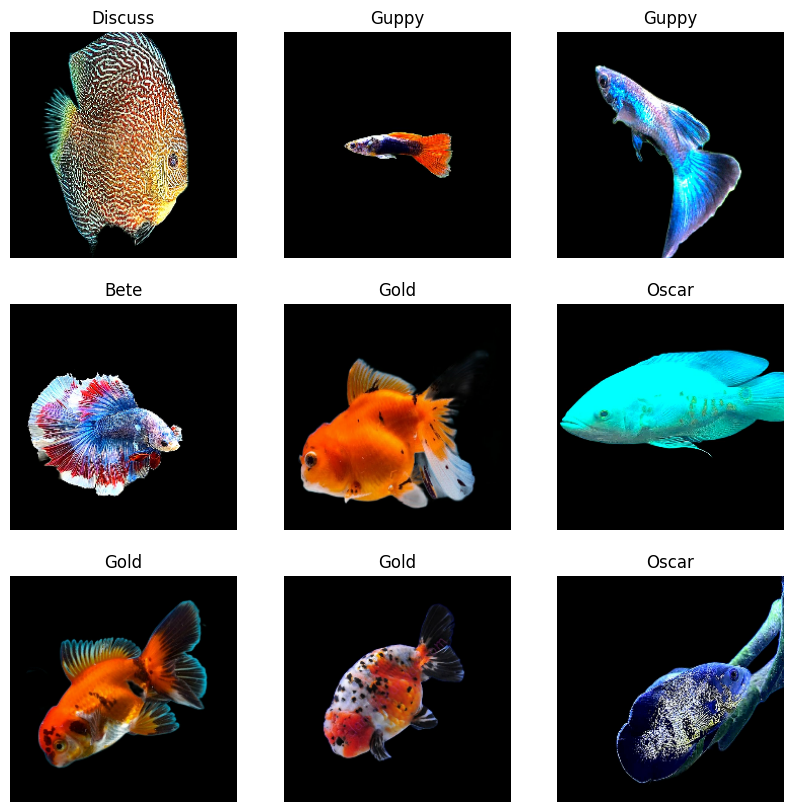

In [24]:
image_batch, label_batch = next(iter(train_ds))


plt.figure(figsize=(10, 10))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)


    plt.imshow(image_batch[i].numpy().astype("uint8"))


    class_name = class_names[label_batch[i]]
    plt.title(class_name)

    plt.axis("off")

plt.show()

In [6]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    actual_data_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    actual_data_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)


Found 1016 files belonging to 6 classes.
Using 813 files for training.
Found 1016 files belonging to 6 classes.
Using 203 files for validation.


In [8]:
class_names = train_ds.class_names

print("\nClasses:")
print(class_names)

num_classes = len(class_names)

label_mapping = {
    idx: name
    for idx, name in enumerate(class_names)
}

with open("label_mapping.pkl", "wb") as f:
    pickle.dump(label_mapping, f)

print("\nLabel mapping saved!")


Classes:
['Bete', 'Cray', 'Discuss', 'Gold', 'Guppy', 'Oscar']

Label mapping saved!


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
])

In [11]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [12]:
base_model.trainable = False

In [13]:
input = keras.Input(shape = (224,224,3))
x = data_augmentation(input)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x,training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(
    num_classes,
    activation="softmax"
    )(x)
model = keras.Model(input,output)

In [14]:
model.compile(
    optimizer = keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
early_stop=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_fish_model.keras',
    monitor='val_loss',
    save_best_only=True)
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        early_stop,
        checkpoint
    ]


)

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 16s 206ms/step - accuracy: 0.5203 - loss: 1.3618 - val_accuracy: 0.8177 - val_loss: 0.5757
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.8438 - loss: 0.5206 - val_accuracy: 0.8916 - val_loss: 0.3309
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - accuracy: 0.8991 - loss: 0.3411 - val_accuracy: 0.9360 - val_loss: 0.2710
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.9151 - loss: 0.2722 - val_accuracy: 0.9409 - val_loss: 0.2139
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.9373 - loss: 0.2080 - val_accuracy: 0.9507 - val_loss: 0.2027
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - accuracy: 0.9508 - loss: 0.1869 - val_accuracy: 0.9409 - val_loss: 0.1763
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 0.9545 - loss: 0.1591 - val_accuracy: 0.9507 - val_loss: 0.1675
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.9656 - loss: 0.1357 - val_accuracy: 

In [16]:
loss, accuracy = model.evaluate(val_ds)

print("\nValidation Accuracy : {:.2f}%".format(accuracy*100))

print("Validation Loss :", loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9606 - loss: 0.1445

Validation Accuracy : 96.06%
Validation Loss : 0.14449669420719147


In [17]:

model.save("best_fish_model.keras")

print("\nModel Saved Successfully!")


Model Saved Successfully!


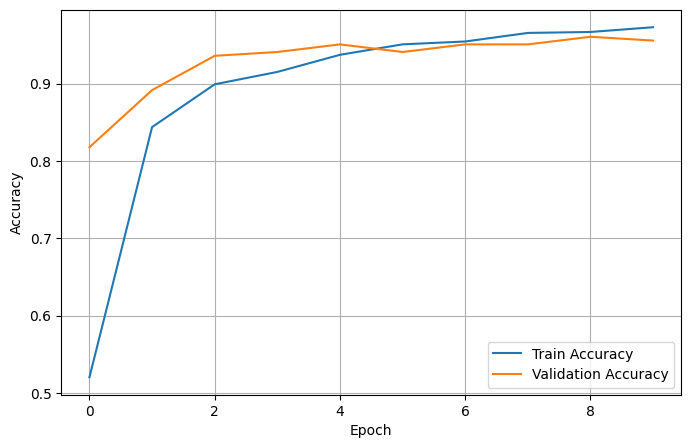

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history_finetune.history["accuracy"], label="Train Accuracy")

plt.plot(history_finetune.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [19]:
import numpy as np
model = keras.models.load_model("/content/best_fish_model.keras")

with open("label_mapping.pkl", "rb") as f:
    label_mapping = pickle.load(f)

# 2. Path to the new image you want to test
# (Put a random fish image in your folder and paste its path here!)
image_path = "/content/Copy of Copy of 490987008_1747932622464523_8647557098307893126_n.jpg"

# 3. Load the image and resize it to (224, 224) just like the model expects
img = keras.utils.load_img(image_path, target_size=(224, 224))

# 4. Convert the image to a math array and add a batch dimension
img_array = keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Model expects shape (1, 224, 224, 3)

# 5. Make the prediction!
predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])  # Convert raw output to percentages

# 6. Find the highest percentage and translate it
predicted_class_idx = np.argmax(predictions[0])
predicted_class_name = label_mapping[predicted_class_idx]
confidence_score = 100 * np.max(score)

# 7. Print the final results
print(f"\n--- 🐠 Prediction Result ---")
print(f"Species: {predicted_class_name}")
print(f"Confidence: {confidence_score:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

--- 🐠 Prediction Result ---
Species: Cray
Confidence: 33.37%


In [21]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[40  0  0  0  1  0]
 [ 0 17  0  0  0  0]
 [ 0  0 36  0  0  0]
 [ 0  0  0 39  1  0]
 [ 0  0  0  0 47  0]
 [ 2  0  0  4  0 16]]
